# Load silver to gold

## Imports

In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Parametros

In [46]:
silver_path = os.path.join(
    os.curdir, "Data_Lake", "Silver"
)
gold_path = os.path.join(
    os.curdir, "Data_Lake", "Gold"
)

In [47]:
silver_file_name = "menstrual_cycle_silver.parquet"

gold_file_name = "menstrual_cycle_gold.parquet"

In [48]:
silver_file_path = os.path.join(
    silver_path, silver_file_name
)
gold_file_path = os.path.join(
    gold_path, gold_file_name
)

## Main

### Cargar los datos de silver

In [49]:
silver_menstrual_cycle_df = pd.read_parquet(silver_file_path)

In [50]:
silver_menstrual_cycle_df.head()

,User ID,Age,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms,BMI,_BronzeTimestamp
index,,,,,,,,,,,,,
0,1.0,18.0,2.0,Moderate,54.0,Low Carb,2024-11-13 20:52:00,26,7.0,2024-12-09 20:52:00,Headache,29.28,2025-11-06 19:16:40.445350
1,1.0,18.0,2.0,Moderate,54.0,Low Carb,2024-12-09 20:52:00,32,5.0,2025-01-10 20:52:00,Fatigue,29.28,2025-11-06 19:16:40.445350
2,1.0,18.0,2.0,Moderate,54.0,Low Carb,2025-01-10 20:52:00,41,7.0,2025-02-20 20:52:00,Fatigue,29.28,2025-11-06 19:16:40.445350
3,1.0,18.0,2.0,Moderate,54.0,Low Carb,2025-02-20 20:52:00,27,3.0,2025-03-19 20:52:00,Fatigue,29.28,2025-11-06 19:16:40.445350
4,1.0,18.0,2.0,Moderate,54.0,Low Carb,2025-03-19 20:52:00,42,5.0,2025-04-30 20:52:00,Cramps,29.28,2025-11-06 19:16:40.445350


### Agrupaciones y medidas

In [85]:
silver_menstrual_cycle_por_user_df = silver_menstrual_cycle_df

# Agrupar por usuario
resumen_por_user = (
    silver_menstrual_cycle_por_user_df .groupby("User ID")
    .agg({
        "Cycle Length": ["mean", "std"],
        "Period Length": "mean",
        "Stress Level": "mean",
        "Sleep Hours": "mean",
        "BMI": "mean",
        "Diet": lambda x: x.mode()[0] if not x.mode().empty else None,
        "Exercise Frequency": lambda x: x.mode()[0] if not x.mode().empty else None,
        "Symptoms": lambda x: x.mode()[0] if not x.mode().empty else None,
        "Cycle Start Date": "count"  # número de ciclos
    })
)

# Renombrar columnas
resumen_por_user.columns = [
    "Avg Cycle Length",
    "Cycle Length Std",
    "Avg Period Length",
    "Avg Stress",
    "Avg Sleep",
    "Avg BMI",
    "Most Common Diet",
    "Most Common Exercise",
    "Most Common Symptom",
    "Cycle Count"
]

resumen_por_user = resumen_por_user.reset_index() #creamos indice

In [88]:
resumen_por_user.head()

,User ID,Avg Cycle Length,Cycle Length Std,Avg Period Length,Avg Stress,Avg Sleep,Avg BMI,Most Common Diet,Most Common Exercise,Most Common Symptom,Cycle Count
0,1.0,36.909091,8.055489,4.909091,2.0,54.0,29.28,Low Carb,Moderate,Fatigue,11
1,2.0,34.444444,6.023104,5.625000,4.0,54.0,29.57,Low Carb,Low,Bloating,9
2,3.0,40.200000,8.689713,4.111111,1.0,86.0,29.44,Vegetarian,Moderate,Cramps,10
3,4.0,40.200000,7.130529,4.800000,2.0,83.0,25.68,Vegetarian,Moderate,Mood Swings,10
4,5.0,38.333333,6.227992,5.333333,1.0,63.0,25.27,Low Carb,High,Bloating,12


### Graficos

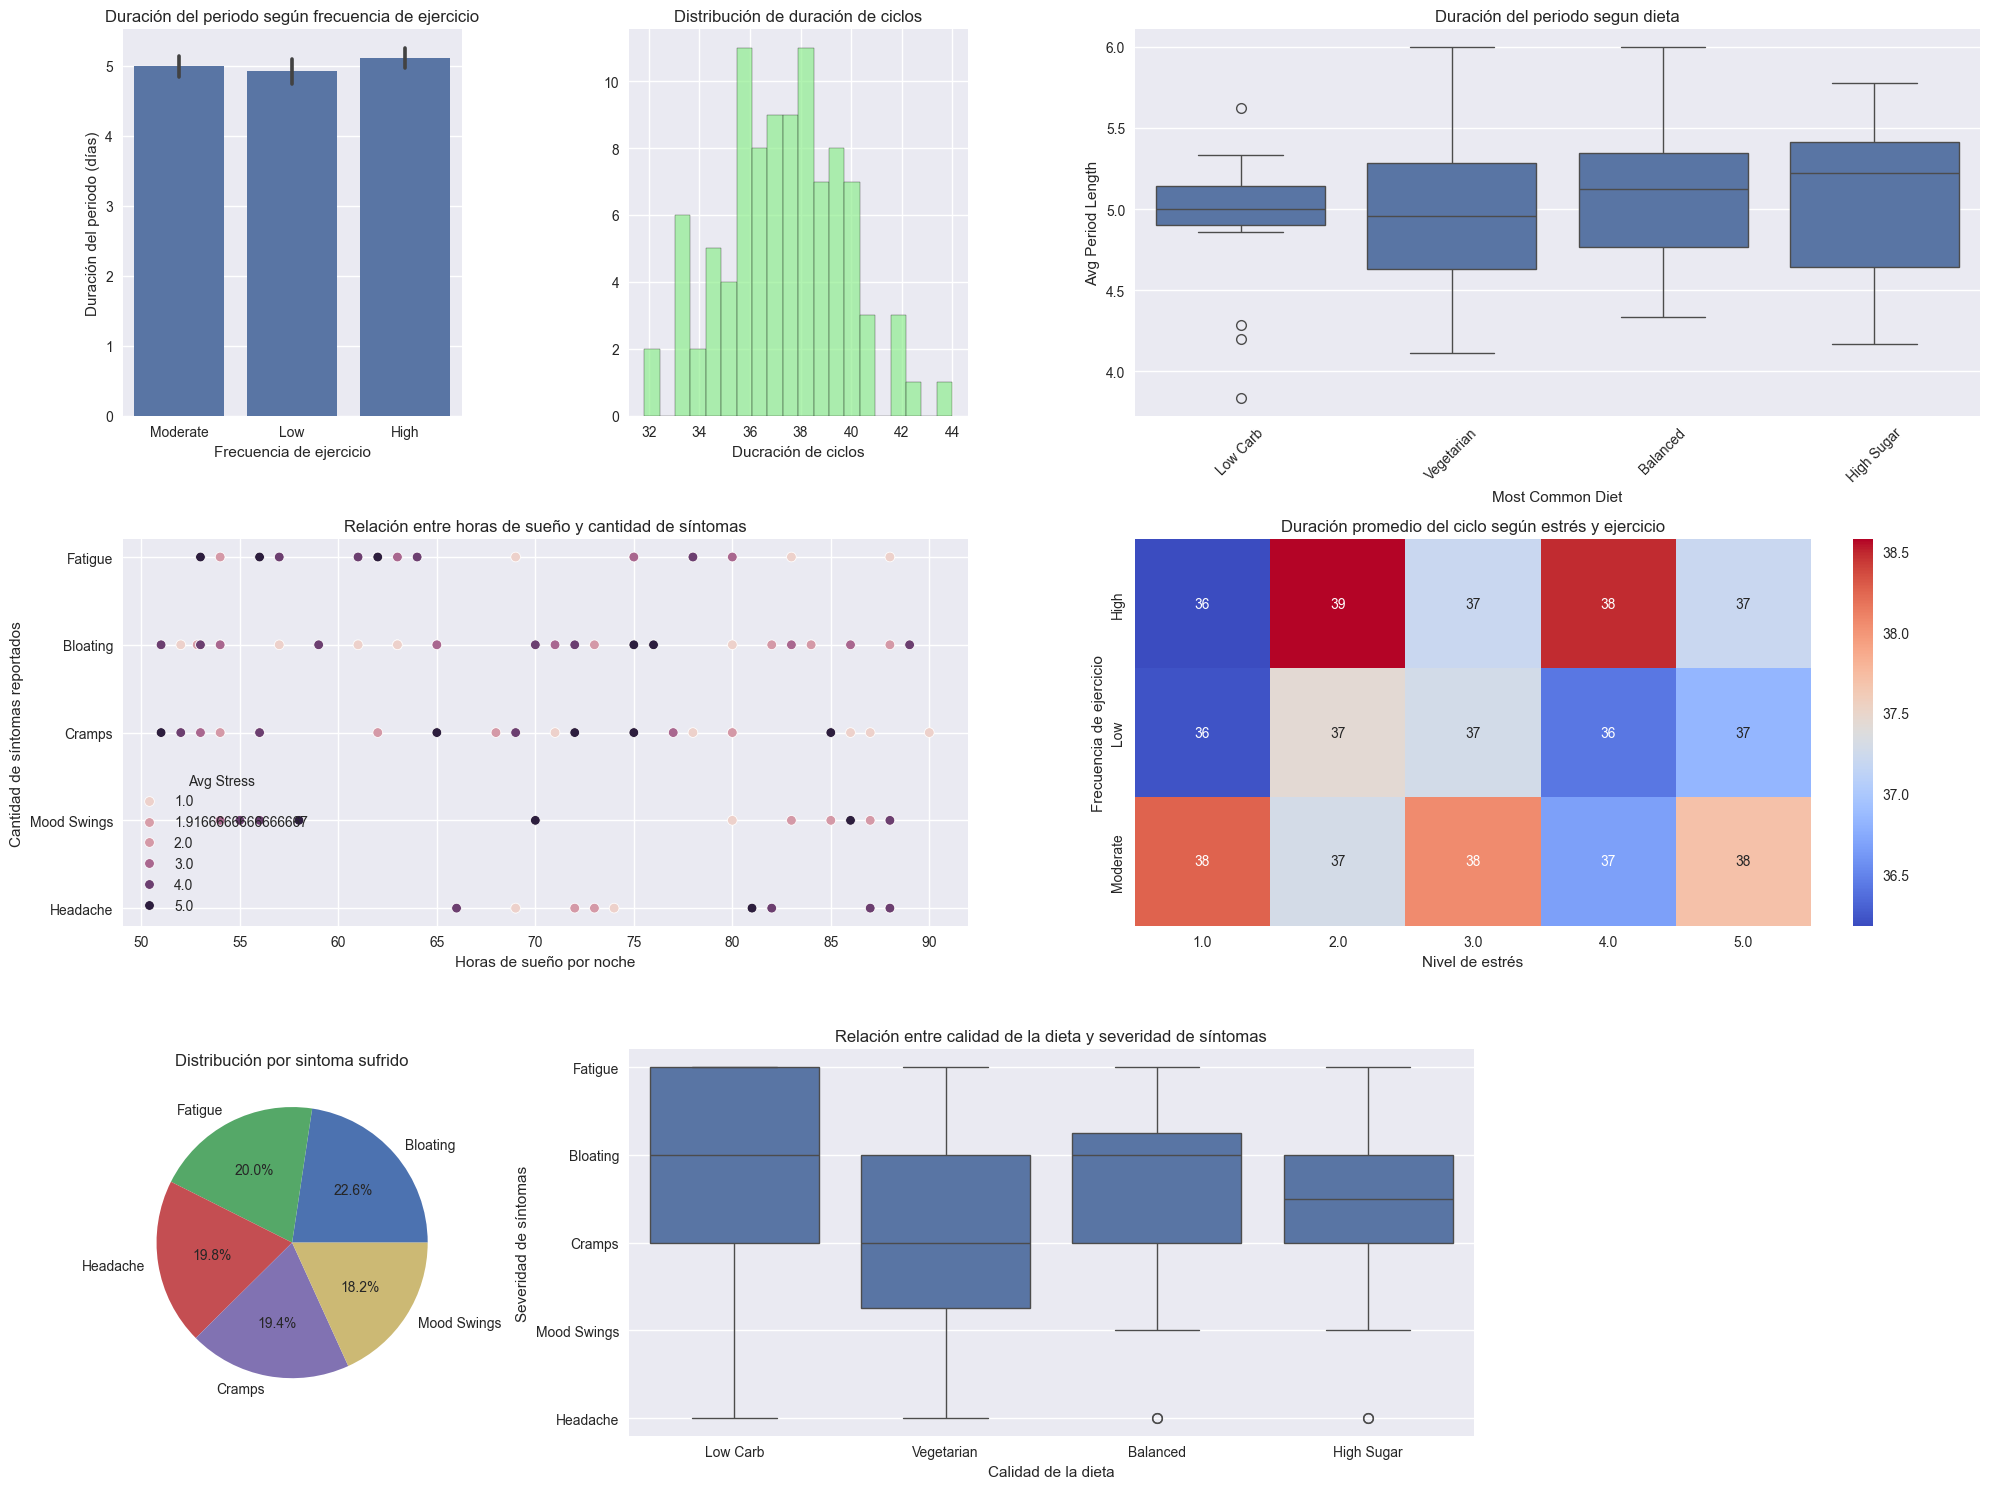


📊 RESUMEN ESTADÍSTICO:
Mujeres totales: 97
Duracion ciclo menstrual promedio: 37.36 días


In [128]:
# Configurar el estilo
plt.style.use('seaborn-v0_8')

# Crear figura principal
fig = plt.figure(figsize=(20, 15))

# 1. 
ax1 = plt.subplot2grid((3, 4), (0, 0))
# sns.boxplot(data=resumen_por_user, x='Avg Stress', y='Avg Cycle Length')
# ax1.set_title('Relación entre niveles de estrés y duración del ciclo')
# ax1.set_xlabel('Nivel de estrés')
# ax1.set_ylabel('Duración del ciclo (días)')

sns.barplot(data=silver_menstrual_cycle_df, x='Exercise Frequency', y='Period Length')
ax1.set_title('Duración del periodo según frecuencia de ejercicio')
ax1.set_xlabel('Frecuencia de ejercicio')
ax1.set_ylabel('Duración del periodo (días)')

# 2. Distribución duración ciclos menstruales
ax2 = plt.subplot2grid((3, 4), (0, 1))
ax2.hist(resumen_por_user['Avg Cycle Length'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.set_title('Distribución de duración de ciclos')
ax2.set_xlabel('Ducración de ciclos')

# 3. Efecto de la dieta
ax3 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
sns.boxplot(data=resumen_por_user, x='Most Common Diet', y='Avg Period Length', ax=ax3)
ax3.set_title('Duración del periodo segun dieta')
ax3.tick_params(axis='x', rotation=45)

# 4. 
ax4 = plt.subplot2grid((3, 4), (1, 0), colspan=2)
sns.scatterplot(data=resumen_por_user, x='Avg Sleep', y='Most Common Symptom', hue='Avg Stress')
ax4.set_title('Relación entre horas de sueño y cantidad de síntomas')
ax4.set_xlabel('Horas de sueño por noche')
ax4.set_ylabel('Cantidad de síntomas reportados')


# 5. Heatmap de correlaciones
ax5 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
# corr_matrix = silver_menstrual_cycle_df.select_dtypes(include=[np.number]).corr()
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax5)
# ax5.set_title('Matriz de Correlación')
pivot = silver_menstrual_cycle_df.pivot_table(values='Cycle Length', 
                       index='Exercise Frequency', 
                       columns='Stress Level', 
                       aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Duración promedio del ciclo según estrés y ejercicio')
plt.xlabel('Nivel de estrés')
plt.ylabel('Frecuencia de ejercicio')


# 6. Análisis de sintomas
ax6 = plt.subplot2grid((3, 4), (2, 0))
compras_por_categoria = silver_menstrual_cycle_df['Symptoms'].value_counts()
ax6.pie(compras_por_categoria.values, labels=compras_por_categoria.index, autopct='%1.1f%%')
ax6.set_title('Distribución por sintoma sufrido')

# 7.
ax7 = plt.subplot2grid((3, 4), (2, 1), colspan=2)
sns.boxplot(data=resumen_por_user, x='Most Common Diet', y='Most Common Symptom')
ax7.set_title('Relación entre calidad de la dieta y severidad de síntomas')
ax7.set_xlabel('Calidad de la dieta')
ax7.set_ylabel('Severidad de síntomas')


plt.tight_layout()
plt.show()

print("\n📊 RESUMEN ESTADÍSTICO:")
print(f"Mujeres totales: {len(resumen_por_user)}")
print(f"Duracion ciclo menstrual promedio: {resumen_por_user['Avg Cycle Length'].mean():.2f} días")

### Guardar

In [ ]:
os.makedirs(gold_path, exist_ok=True)

In [ ]:
silver_menstrual_cycle_df.to_parquet(gold_file_path)